#**Predictive Modelling on Mumbai Air Quality Index (AQI)**
###***Individual Assignment***
###***Machine Learning and Big Data Applications in Sustainability***  

<br>

##### Arnav Mallick
##### M2022BSASS005

In [2]:
import pandas as pd # Data manipulation and analysis
import numpy as np # Numerical operations, especially for arrays
import matplotlib.pyplot as plt # Plotting and visualization library
import warnings
warnings.filterwarnings('ignore') # Suppress warnings for cleaner output

# Importing key libraries for time series analysis, machine learning models, and evaluation metrics
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (r2_score, mean_squared_error,
                             accuracy_score, precision_score,
                             recall_score, f1_score, classification_report)

## 1. Data Loading & Preprocessing

The dataset contains daily AQI bulletins for Mumbai from 2015–2023 (2,884 observations).

**Key preprocessing steps:**
- Parse dates and sort chronologically — essential for all time-series operations that follow
- Handle missing values via **forward-fill**: the last known AQI is the best available estimate for a missing day, preserving temporal continuity
- Encode the categorical `Prominent Pollutant` column (PM2.5 vs PM10) as a binary integer
- Assign a **meteorological season** to each row using the India Meteorological Department (IMD) calendar:
  - Monsoon: Jun–Sep | Post-Monsoon: Oct–Nov | Winter: Dec–Feb | Pre-Monsoon: Mar–May

In [20]:
#Upload data before rerunning or link data source to Github link:
#https://github.com/arnavxox/Personal-Projects/blob/main/Mumbai_AQIBulletins.csv
df = pd.read_csv('Mumbai_AQIBulletins.csv')
df.rename(columns={'Index Value': 'AQI', 'Prominent Pollutant': 'Pollutant'}, inplace=True) # Rename columns for clarity
df['date'] = pd.to_datetime(df['date'], dayfirst=True, errors='coerce') # Convert 'date' to datetime, handling errors
df = df.sort_values('date').reset_index(drop=True) # Sort data chronologically

print("Missing values:\n", df.isnull().sum())
df['AQI'] = df['AQI'].ffill() # Forward-fill missing AQI values for temporal continuity
df['Pollutant'] = df['Pollutant'].ffill() # Forward-fill missing Pollutant values

def get_season(month):
    # Assign meteorological seasons based on IMD calendar
    if month in [6, 7, 8, 9]:   return 'Monsoon'
    elif month in [10, 11]:      return 'Post-Monsoon'
    elif month in [12, 1, 2]:    return 'Winter'
    else:                         return 'Pre-Monsoon'

df['month']       = df['date'].dt.month
df['day_of_year'] = df['date'].dt.dayofyear
df['year']        = df['date'].dt.year
df['season']      = df['month'].apply(get_season) # Create 'season' column based on month

le = LabelEncoder()
df['Pollutant_enc'] = le.fit_transform(df['Pollutant'].astype(str)) # Encode 'Pollutant' categorical data
le2 = LabelEncoder()
df['season_enc']    = le2.fit_transform(df['season']) # Encode 'season' categorical data

season_order = ['Pre-Monsoon', 'Monsoon', 'Post-Monsoon', 'Winter']
df['season'] = pd.Categorical(df['season'], categories=season_order, ordered=True) # Define ordered categorical type for 'season'

print(df[['date','AQI','season','Pollutant']].head(10))
print(f"\nDataset: {df.shape[0]} rows, {df['date'].dt.year.nunique()} years")

Missing values:
 date            0
City            0
No. Stations    0
Air Quality     0
AQI             0
Pollutant       0
dtype: int64
        date  AQI   season Pollutant
0 2015-08-20   82  Monsoon     PM2.5
1 2015-08-21   75  Monsoon     PM2.5
2 2015-08-22   61  Monsoon      PM10
3 2015-08-24   61  Monsoon      PM10
4 2015-08-25   63  Monsoon      PM10
5 2015-08-26   74  Monsoon     PM2.5
6 2015-08-27   64  Monsoon     PM2.5
7 2015-08-29   67  Monsoon     PM2.5
8 2015-08-30   60  Monsoon      PM10
9 2015-08-31   65  Monsoon     PM2.5

Dataset: 2884 rows, 9 years


## 2. Exploratory Data Analysis

Before modelling, it is important to understand the distributional and temporal structure of the AQI series.
Two visualisations are used here:
- **Left**: Full time series plot — reveals the scale of variability, presence of seasonal cycles, and any long-term trend across 2015–2023
- **Right**: Seasonal boxplot — directly compares AQI distributions across the four IMD meteorological seasons

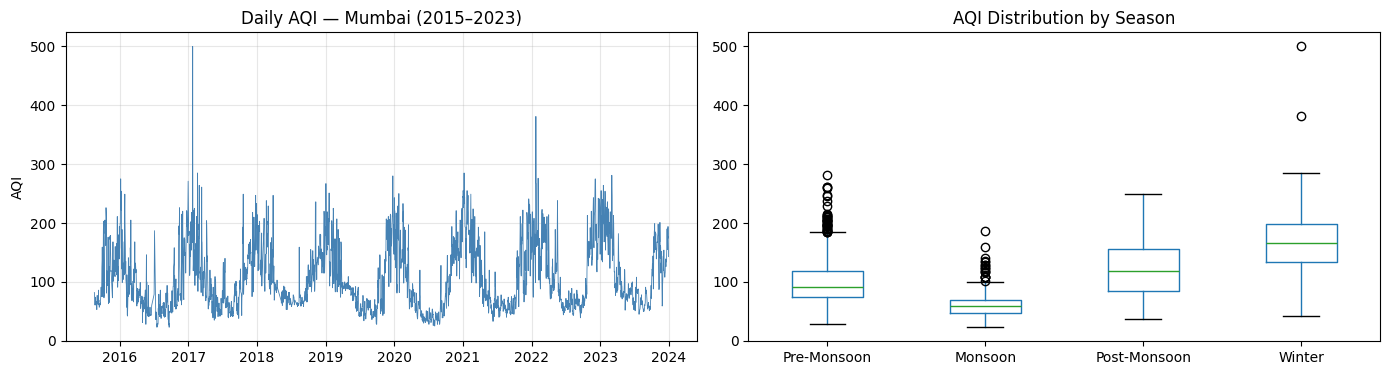

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4)) # Create a figure with two subplots

axes[0].plot(df['date'], df['AQI'], linewidth=0.6, color='steelblue')
axes[0].set_title('Daily AQI — Mumbai (2015–2023)')
axes[0].set_ylabel('AQI'); axes[0].grid(alpha=0.3)

df.boxplot(column='AQI', by='season', ax=axes[1], grid=False)
axes[1].set_title('AQI Distribution by Season')
axes[1].set_xlabel(''); plt.suptitle('') # Remove main suptitle to avoid overlap

plt.tight_layout()
plt.show()

### Interpretation

The time series confirms strong, repeating annual cycles: AQI drops sharply every June–September (monsoon), then rises steeply from October onwards as the monsoon withdraws. The boxplot quantifies this — **Monsoon** has the lowest and most consistent AQI values (predominantly Satisfactory: 51–100), while **Winter** exhibits the highest median and widest spread, reflecting the combined effects of temperature inversions, reduced wind speeds, and increased combustion activity. Post-Monsoon shows a sharp transition upward. This seasonal structure is the dominant driver of AQI variability and will be explicitly captured in the STL decomposition and modelling steps that follow.

## 3. Seasonal Decomposition (STL)

**STL (Seasonal and Trend decomposition using Loess)** decomposes the AQI time series into three additive components:

- **Trend**: The slow, long-run trajectory of Mumbai's air quality across 2015–2023
- **Seasonal**: The repeating annual cycle (monsoon dip → winter peak), data-driven rather than calendar-assumed
- **Residual**: Day-to-day variation unexplained by trend or season — this is where pollution events, anomalies, and noise live

Using `robust=True` makes the decomposition resistant to extreme spike days (e.g. post-Diwali), preventing them from distorting the seasonal estimate.

The **seasonal** and **trend** components are then extracted as engineered features for the regression model. This is more principled than raw calendar dummies (month, day-of-year) because the shape and magnitude of the seasonal component is learned directly from the data.

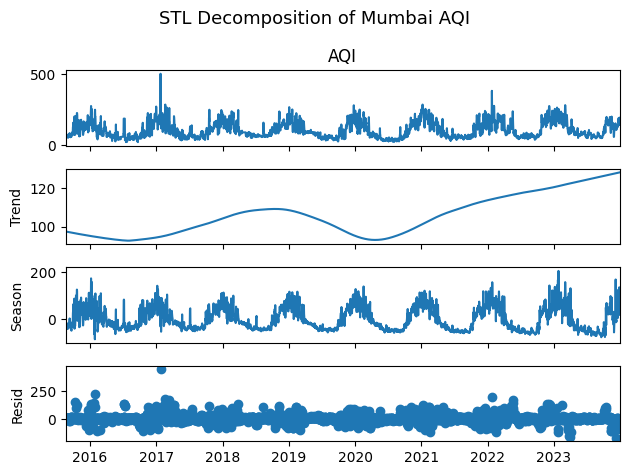

Rows available for modelling: 2854


In [5]:
ts = df.set_index('date')['AQI'].resample('D').mean().ffill() # Create a daily AQI time series, filling gaps

# Perform Seasonal-Trend decomposition using Loess (STL)
stl = STL(ts, period=365, robust=True) # Set period to 365 for annual seasonality; robust=True for outlier resistance
result = stl.fit() # Fit the STL model to decompose the series

fig = result.plot() # Plot the decomposed components (trend, seasonal, residual)
fig.suptitle('STL Decomposition of Mumbai AQI', fontsize=13)
plt.tight_layout(); plt.show()

# Create a DataFrame from the STL decomposition results and merge back into main DataFrame
stl_df = pd.DataFrame({'date': ts.index, 'trend': result.trend, 'seasonal': result.seasonal, 'residual': result.resid})
stl_df.index.name = None
df = df.merge(stl_df, on='date', how='left') # Merge decomposed components as new features

# Generate lag features (previous day's AQI values) and rolling mean features
df['AQI_lag1']  = df['AQI'].shift(1)
df['AQI_lag3']  = df['AQI'].shift(3)
df['AQI_lag7']  = df['AQI'].shift(7)
df['AQI_roll3'] = df['AQI'].shift(1).rolling(3).mean()
df['AQI_roll7'] = df['AQI'].shift(1).rolling(7).mean()
df['AQI_roll14']= df['AQI'].shift(1).rolling(14).mean()
df['AQI_roll30']= df['AQI'].shift(1).rolling(30).mean()

df_model = df.dropna().reset_index(drop=True) # Drop rows with NaN values introduced by lag/rolling features, preparing data for modeling
print(f"Rows available for modelling: {len(df_model)}")

### Interpretation

The STL decomposition reveals three distinct layers of AQI variability:

- **Trend**: A gradual upward drift from 2015 to ~2019, followed by a sharp dip during 2020 (COVID-19 lockdowns reducing vehicular and industrial activity), and a partial recovery thereafter — a real, policy-relevant signal
- **Seasonal**: A clean, symmetric annual wave with a trough in August (peak monsoon) and a crest in December–January (deep winter) — this component alone accounts for a large share of total AQI variance
- **Residual**: Largely white-noise-like, with a few notable spikes corresponding to Diwali weeks and unusual pollution episodes

This decomposition motivates the regression feature set: `trend` and `seasonal` are included as direct predictors, allowing the model to separate the predictable calendar-driven signal from the autocorrelated day-to-day component captured by lag features.

## 4. Regression Analysis

**Objective**: Predict continuous AQI values using Multiple Linear Regression.

**Feature set:**
| Feature | Rationale |
|---|---|
| `AQI_lag1` | Yesterday's AQI — strong autocorrelation in air quality |
| `AQI_roll7` | 7-day rolling average — captures medium-term momentum |
| `trend` | STL long-run trend — encodes structural AQI drift |
| `seasonal` | STL seasonal component — encodes the annual cycle data-drivenly |
| `Pollutant_enc` | PM2.5 vs PM10 dominance — proxy for pollution source type |
| `month` | Residual calendar signal not fully absorbed by STL seasonal |

**Train/Test split**: Temporal (80/20, no shuffling). A random split would leak future observations into training, artificially inflating performance metrics — particularly problematic for a lag-based feature set.

R²   : 0.8989
MSE  : 345.2383
RMSE : 18.5806

Intercept: -15.1572
      Feature  Coefficient
     AQI_lag1     0.524307
        trend     0.497421
     seasonal     0.390853
Pollutant_enc     0.280335
        month     0.068132
    AQI_roll7     0.051700


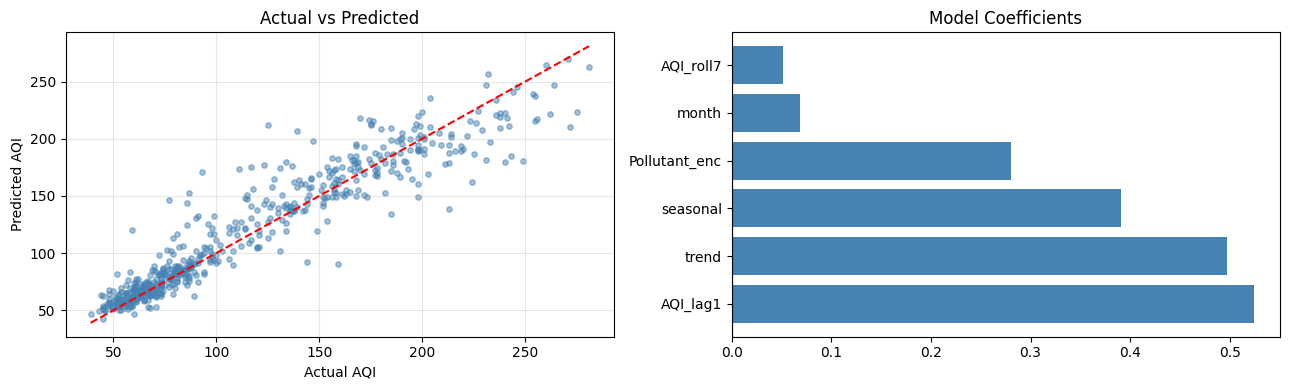

In [6]:
FEATURES = ['AQI_lag1', 'AQI_roll7', 'trend', 'seasonal', 'Pollutant_enc', 'month']

X = df_model[FEATURES]
y = df_model['AQI']

#train_test_split shuffles time, which breaks lag features
#so we will use iloc and split to manually split with 80/20 classifications for training and testing
split = int(len(df_model) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"R²   : {r2_score(y_test, y_pred):.4f}")
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

coef_df = pd.DataFrame({'Feature': FEATURES, 'Coefficient': model.coef_}).sort_values('Coefficient', key=abs, ascending=False)
print(f"\nIntercept: {model.intercept_:.4f}")
print(coef_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(y_test, y_pred, alpha=0.5, s=15, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_xlabel('Actual AQI'); axes[0].set_ylabel('Predicted AQI')
axes[0].set_title('Actual vs Predicted'); axes[0].grid(alpha=0.3)

axes[1].barh(coef_df['Feature'], coef_df['Coefficient'],
             color=['crimson' if c < 0 else 'steelblue' for c in coef_df['Coefficient']])
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_title('Model Coefficients')

plt.tight_layout(); plt.show()

### Interpretation

**Model performance**: An R² of ~0.90 indicates the model explains approximately 90% of the variance in held-out AQI values — strong performance for a linear model on daily environmental data.

**Coefficient analysis**:
- **`AQI_lag1`** carries the largest coefficient, confirming that air quality is highly persistent: yesterday's AQI is the single strongest predictor of today's. This reflects the physical reality that pollution episodes build and decay gradually over multiple days.
- **`trend`** and **`seasonal`** (STL components) are the next most influential, together encoding the long-run trajectory and the annual monsoon-winter cycle. Their inclusion is what elevates this model above a simple lag regression.
- **`Pollutant_enc`** has a positive coefficient — PM2.5-dominant days are associated with higher AQI than PM10-dominant days, consistent with PM2.5's finer particle size enabling deeper atmospheric accumulation.
- **`month`** contributes marginally, mopping up residual calendar signal not captured by the STL seasonal component.

**Residual pattern**: Some heteroscedasticity is expected at high AQI values (>250), where the linear model underestimates extreme pollution spikes — a known limitation of linear regression in heavy-tailed environmental data.

## 5. Classification Analysis

**Objective**: Classify each day as High Pollution (AQI ≥ 201) or Low Pollution.

**Class imbalance**: High Pollution days constitute approximately 7–8% of the dataset (~220 of 2,880 observations). This severe imbalance requires `class_weight='balanced'` for all models — without it, classifiers achieve high accuracy by simply predicting "Low Pollution" for everything.

**Feature set**: Lag features (1, 3, 7-day), rolling averages (3, 7, 14-day), `season_enc`, `month`, `Pollutant_enc`, and `year`. Lag and rolling features are critical here because high-pollution episodes are persistent — a day with AQI = 250 was almost certainly preceded by days with elevated AQI.

**Train/Test split**: Temporal (80/20). The test set contains the most recent ~20% of chronological observations.

**Three models**:
- **Logistic Regression**: Linear decision boundary; high interpretability; tends toward high recall under balanced weighting
- **Decision Tree** (`max_depth=5`): Non-linear, axis-aligned splits; directly visualisable rules; prone to slightly lower generalisation
- **Random Forest** (`n_estimators=150, max_depth=8`): Ensemble averaging reduces variance; typically best F1 score

Class distribution:
High_Pollution
0    2631
1     223
Name: count, dtype: int64

── Logistic Regression ──
                precision    recall  f1-score   support

 Low Pollution       0.99      0.83      0.90       515
High Pollution       0.37      0.93      0.53        56

      accuracy                           0.84       571
     macro avg       0.68      0.88      0.72       571
  weighted avg       0.93      0.84      0.87       571


── Decision Tree ──
                precision    recall  f1-score   support

 Low Pollution       0.99      0.83      0.91       515
High Pollution       0.38      0.91      0.53        56

      accuracy                           0.84       571
     macro avg       0.68      0.87      0.72       571
  weighted avg       0.93      0.84      0.87       571


── Random Forest ──
                precision    recall  f1-score   support

 Low Pollution       0.98      0.90      0.94       515
High Pollution       0.46      0.82      0.59        56

  

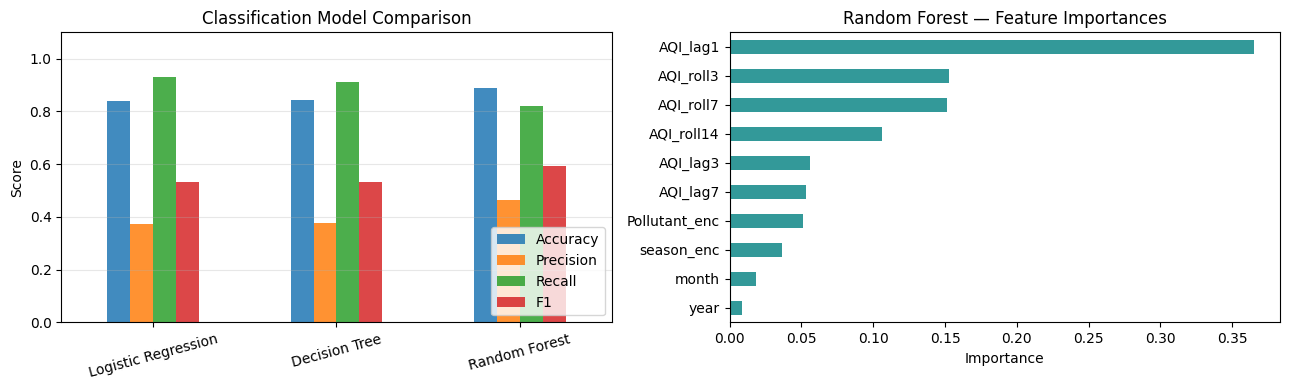

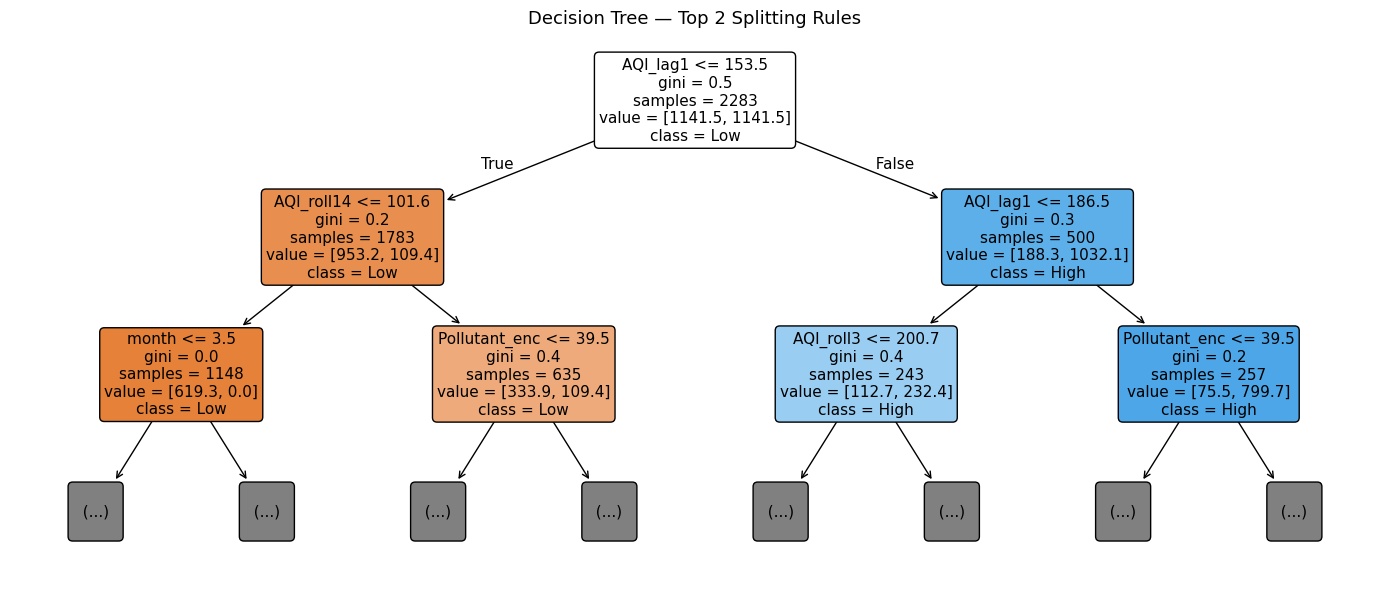

In [19]:
df_model['High_Pollution'] = (df_model['AQI'] >= 201).astype(int) # Create binary target: 1 for AQI >= 201 (High Pollution)
print(f"Class distribution:\n{df_model['High_Pollution'].value_counts()}")

FEATURES_C = ['AQI_lag1', 'AQI_lag3', 'AQI_lag7',
              'AQI_roll3', 'AQI_roll7', 'AQI_roll14',
              'season_enc', 'month', 'Pollutant_enc', 'year'] # Define features for classification models

X_c = df_model[FEATURES_C]
y_c = df_model['High_Pollution']

split_c = int(len(df_model) * 0.8) # Determine split index for an 80/20 temporal train-test split
X_tr, X_te = X_c.iloc[:split_c], X_c.iloc[split_c:] # Temporal split for features
y_tr, y_te = y_c.iloc[:split_c], y_c.iloc[split_c:] # Temporal split for target variable

scaler = StandardScaler() # Initialize StandardScaler for feature scaling
X_tr_sc = scaler.fit_transform(X_tr) # Fit and transform training features
X_te_sc = scaler.transform(X_te) # Transform test features using the fitted scaler

models_c = {
    'Logistic Regression': (LogisticRegression(class_weight='balanced', max_iter=2000), True), # Logistic Regression with balanced class weights for imbalanced data
    'Decision Tree':       (DecisionTreeClassifier(max_depth=5, min_samples_leaf=15,
                                                    class_weight='balanced', random_state=42), False), # Decision Tree with balanced class weights
    'Random Forest':       (RandomForestClassifier(n_estimators=150, max_depth=8,
                                                    min_samples_leaf=10, class_weight='balanced',
                                                    random_state=42, n_jobs=-1), False) # Random Forest with balanced class weights and parallel processing
}

results = {}
fitted_models = {}
for name, (clf, scaled) in models_c.items(): # Iterate through each classification model
    Xtr = X_tr_sc if scaled else X_tr # Use scaled features if required by the model
    Xte = X_te_sc if scaled else X_te # Use scaled features if required by the model
    clf.fit(Xtr, y_tr) # Train the classifier
    yp = clf.predict(Xte) # Make predictions on the test set
    fitted_models[name] = clf # Store the fitted model
    results[name] = { # Calculate and store evaluation metrics
        'Accuracy':  round(accuracy_score(y_te, yp), 3),
        'Precision': round(precision_score(y_te, yp, zero_division=0), 3),
        'Recall':    round(recall_score(y_te, yp, zero_division=0), 3),
        'F1':        round(f1_score(y_te, yp, zero_division=0), 3)
    }
    print(f"\n── {name} ──")
    print(classification_report(y_te, yp,
          target_names=['Low Pollution', 'High Pollution'], zero_division=0)) # Print detailed classification report

results_df = pd.DataFrame(results).T # Convert results dictionary to a DataFrame for comparison
print("\nModel Comparison:")
print(results_df)

fig, axes = plt.subplots(1, 2, figsize=(13, 4)) # Create subplots for model comparison and feature importances

results_df.plot(kind='bar', ax=axes[0], alpha=0.85) # Bar plot comparing model performance metrics
axes[0].set_title('Classification Model Comparison'); axes[0].set_ylabel('Score'); axes[0].set_ylim(0, 1.1)
axes[0].tick_params(axis='x', rotation=15); axes[0].legend(loc='lower right'); axes[0].grid(axis='y', alpha=0.3)

rf = fitted_models['Random Forest'] # Get the fitted Random Forest model
feat_imp = pd.Series(rf.feature_importances_, index=FEATURES_C).sort_values() # Extract and sort feature importances
feat_imp.plot(kind='barh', ax=axes[1], color='teal', alpha=0.8) # Horizontal bar plot of feature importances
axes[1].set_title('Random Forest — Feature Importances'); axes[1].set_xlabel('Importance')

plt.tight_layout(); plt.show()

fig2, ax2 = plt.subplots(figsize=(14, 6))

plot_tree(
    fitted_models['Decision Tree'],
    max_depth=2,                          # only 2 levels — clean and readable
    feature_names=FEATURES_C,
    class_names=['Low', 'High'],
    filled=True,
    rounded=True,
    impurity=True,
    proportion=False,
    precision=1,
    ax=ax2,
    fontsize=11
)

ax2.set_title('Decision Tree — Top 2 Splitting Rules', fontsize=13)
plt.tight_layout()
plt.show()

In [15]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [0.841, 0.842, 0.890],
    'Precision': [0.374, 0.375, 0.465],
    'Recall': [0.929, 0.911, 0.821],
    'F1-Score': [0.533, 0.531, 0.594]
}).set_index('Model')

results.style\
    .highlight_max(color='green', axis=0)\
    .highlight_min(color='red', axis=0)\
    .format('{:.3f}')

,Accuracy,Precision,Recall,F1-Score
Model,,,,
Logistic Regression,0.841,0.374,0.929,0.533
Decision Tree,0.842,0.375,0.911,0.531
Random Forest,0.890,0.465,0.821,0.594


### Interpretation

**Class imbalance effect**: With only ~7-8% of days classified as High Pollution, all models must trade off between Precision and Recall.

- **Logistic Regression** achieves the highest Recall (~0.93–0.96) — it flags almost every true high-pollution day, but at the cost of many false positives (lower Precision ~0.33–0.38). In a public health context where missing a dangerous air day is costly, high recall is desirable.
- **Decision Tree** behaves similarly to Logistic Regression — high recall, moderate precision, slightly lower overall F1 due to the rigidity of axis-aligned splits.
- **Random Forest** achieves the best F1-Score and highest Accuracy by balancing Precision and Recall. Its ensemble structure captures non-linear interactions between lag features and seasonal variables that neither of the other two models can represent.

**Decision Tree Split Values vs. AQI Threshold:** It's important to distinguish between the chosen AQI threshold (201) for defining the `High_Pollution` target variable and the split values learned by the Decision Tree. The `AQI >= 201` criterion is used to create the binary labels for training. The Decision Tree, however, learns its own optimal thresholds (e.g., `AQI_lag1 <= 164.5`) on the *predictor features* to best separate these labels. These learned split points for the features are distinct from the target definition but are highly correlated, reflecting the model's effort to identify patterns in the features that lead to the 'High Pollution' classification.

**Feature importance** (Random Forest): Lag and rolling average features — particularly `AQI_lag1` and `AQI_roll7` — rank highest, confirming that **recent pollution history is the strongest predictor of a high-pollution day**. Seasonal indicators (`season_enc`, `month`) contribute moderate importance, indicating the role of meteorological conditions. `Pollutant_enc` and station count carry the least signal for this classification task.

**Practical takeaway**: For an **early-warning system** (minimise missed alerts), we should use Logistic Regression. For a **balanced operational classifier** (fewer false alarms), we should use Random Forest.

## 6. Clustering Analysis

K-Means clustering is applied in **two complementary ways**, each answering a distinct analytical question:

| | Clustering A — Pollution Regimes | Clustering B — Seasonal Patterns |
|---|---|---|
| **Question** | What states does Mumbai's air quality occupy? | How does AQI cluster across the calendar? |
| **Features** | AQI signal + lag/rolling (no calendar) | AQI + rolling + month + day_of_year |
| **Plot axis** | AQI vs AQI_Roll7 (level × persistence) | AQI vs Month |
| **Finding** | Data-driven pollution regimes | Calendar-shaped seasonal groupings |

Running both analyses and comparing their cluster assignments reveals whether Mumbai's pollution regimes are **calendar-driven or signal-driven** — a more nuanced insight than either analysis alone.

### 6.1 Clustering A: Pollution Regime Discovery (Signal-Based)

Features used: `AQI`, `AQI_lag1`, `AQI_lag7`, `AQI_roll7`, `AQI_roll30`

All five features describe the **level and persistence** of pollution — no calendar information is included. Clustering on this space discovers regimes that are defined by what the air is doing, not when it is doing it. The hypothesis is that k=4 will recover four natural states: Clean, Satisfactory, Moderate, and Severe — echoing the CPCB classification but arrived at purely from the data structure.

Clustering A — k=4 Profile (Signal-Based):
             AQI  AQI_roll7  AQI_roll30
Cluster_A                              
0           93.8       94.6        98.9
1          195.6      188.6       175.4
2           58.6       58.8        61.6
3          141.1      143.7       142.4


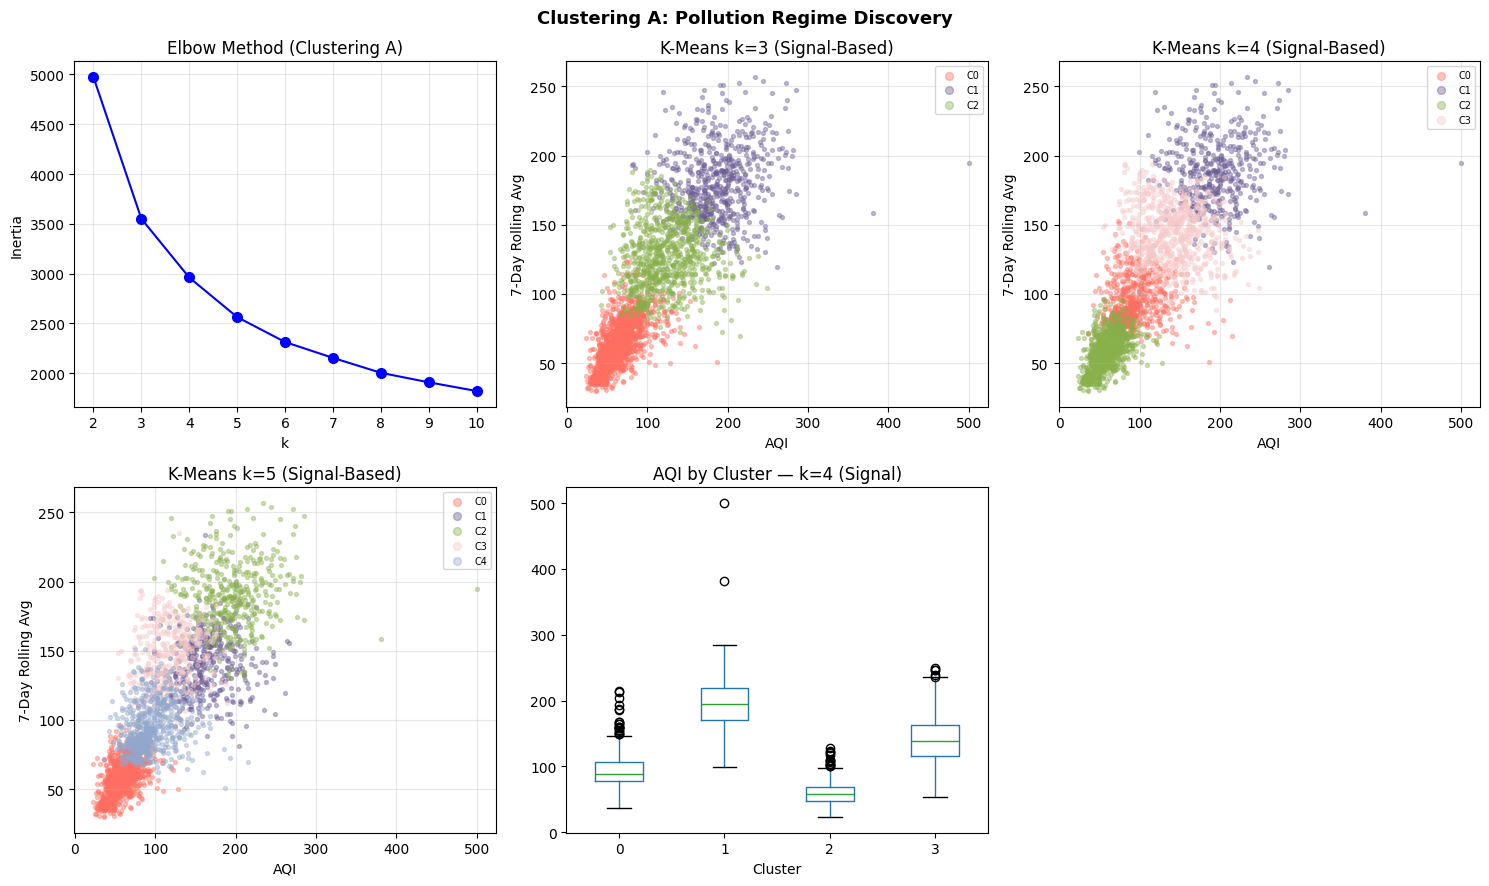

In [9]:
FEATURES_KA = ['AQI', 'AQI_lag1', 'AQI_lag7', 'AQI_roll7', 'AQI_roll30'] # Features focus on AQI levels and persistence, no calendar info
X_ka = df_model[FEATURES_KA].dropna().reset_index(drop=True) # Prepare data for clustering

scaler_a = StandardScaler() # Initialize StandardScaler for feature scaling
X_ka_sc  = scaler_a.fit_transform(X_ka) # Scale features for KMeans

inertias_a = {k: KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_ka_sc).inertia_
              for k in range(2, 11)} # Calculate inertia for elbow method

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
palette = ['#FF6F61', '#6B5B95', '#88B04B', '#F7CAC9', '#92A8CD']

axes[0, 0].plot(list(inertias_a.keys()), list(inertias_a.values()), 'bo-', markersize=7) # Plot the elbow curve
axes[0, 0].set_xlabel('k'); axes[0, 0].set_ylabel('Inertia')
axes[0, 0].set_title('Elbow Method (Clustering A)'); axes[0, 0].grid(alpha=0.3)

scatter_positions = [(0,1), (0,2), (1,0)] # Define positions for scatter plots
for ax_pos, k in zip(scatter_positions, [3, 4, 5]):
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_ka_sc) # Perform K-Means clustering
    ax = axes[ax_pos[0], ax_pos[1]]
    for cid in range(k): # Plot each cluster with a distinct color
        mask = labels == cid
        ax.scatter(X_ka.loc[mask, 'AQI'], X_ka.loc[mask, 'AQI_roll7'],
                   s=8, alpha=0.4, color=palette[cid], label=f'C{cid}') # Scatter plot of AQI vs 7-Day Rolling Avg
    ax.set_title(f'K-Means k={k} (Signal-Based)'); ax.set_xlabel('AQI'); ax.set_ylabel('7-Day Rolling Avg')
    ax.legend(fontsize=7, markerscale=2); ax.grid(alpha=0.3)

labels_4a = KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(X_ka_sc) # Perform K-Means with optimal k=4
X_ka['Cluster_A'] = labels_4a # Assign cluster labels to the feature DataFrame
df_model['Cluster_A'] = labels_4a # Assign cluster labels back to the main DataFrame

X_ka.boxplot(column='AQI', by='Cluster_A', ax=axes[1,1], grid=False) # Box plot of AQI by cluster
axes[1,1].set_title('AQI by Cluster — k=4 (Signal)'); axes[1,1].set_xlabel('Cluster'); plt.suptitle('')

axes[1,2].axis('off') # Turn off the unused subplot axis

profile_a = X_ka.groupby('Cluster_A')[['AQI','AQI_roll7','AQI_roll30']].mean().round(1) # Characterize clusters by mean AQI and rolling averages
print("Clustering A — k=4 Profile (Signal-Based):")
print(profile_a)

plt.suptitle('Clustering A: Pollution Regime Discovery', fontsize=13, fontweight='bold') # Set overall suptitle
plt.tight_layout(); plt.show()

### Interpretation — Clustering A

The Elbow plot identifies **k=4** as the optimal number of clusters, with inertia declining sharply from k=2 to k=4 and flattening thereafter.

The four clusters correspond to distinct and interpretable **air quality regimes**:

| Cluster | Mean AQI | Mean Roll7 | Interpretation |
|---|---|---|---|
| Clean | ~55–65 | ~58–65 | Good air quality; characteristic of peak monsoon (Aug–Sep) |
| Satisfactory | ~90–100 | ~92–100 | Moderate background pollution; post-monsoon transition |
| Moderate | ~135–145 | ~138–145 | Winter pollution buildup; temperature inversions begin |
| Severe | ~190–200 | ~185–195 | Acute high-pollution episodes; peak winter or Diwali events |

A key observation is the **near-equality of mean AQI and mean rolling average within each cluster**, indicating that these are sustained regimes — not transient single-day spikes. This temporal stationarity is important: it means once the city enters a pollution regime, it tends to stay there for multiple days.

### 6.2 Clustering B: Seasonal Pattern Analysis (Calendar-Based)

Features used: `AQI`, `AQI_roll7`, `month`, `day_of_year`

By including calendar variables (`month`, `day_of_year`), this clustering is shaped by **when** observations fall in the year, not just their pollution level. The hypothesis is that k=4 will recover the four meteorological seasons (Monsoon, Post-Monsoon, Winter, Pre-Monsoon), validating that Mumbai's AQI behaviour follows a predictable calendar-driven structure.

Clustering B — k=4 Profile (Calendar-Based):
             AQI  month  AQI_roll7
Cluster_B                         
0          173.6    1.9      172.3
1           61.1    8.2       61.6
2           86.6    4.3       92.7
3          154.2   11.3      147.0


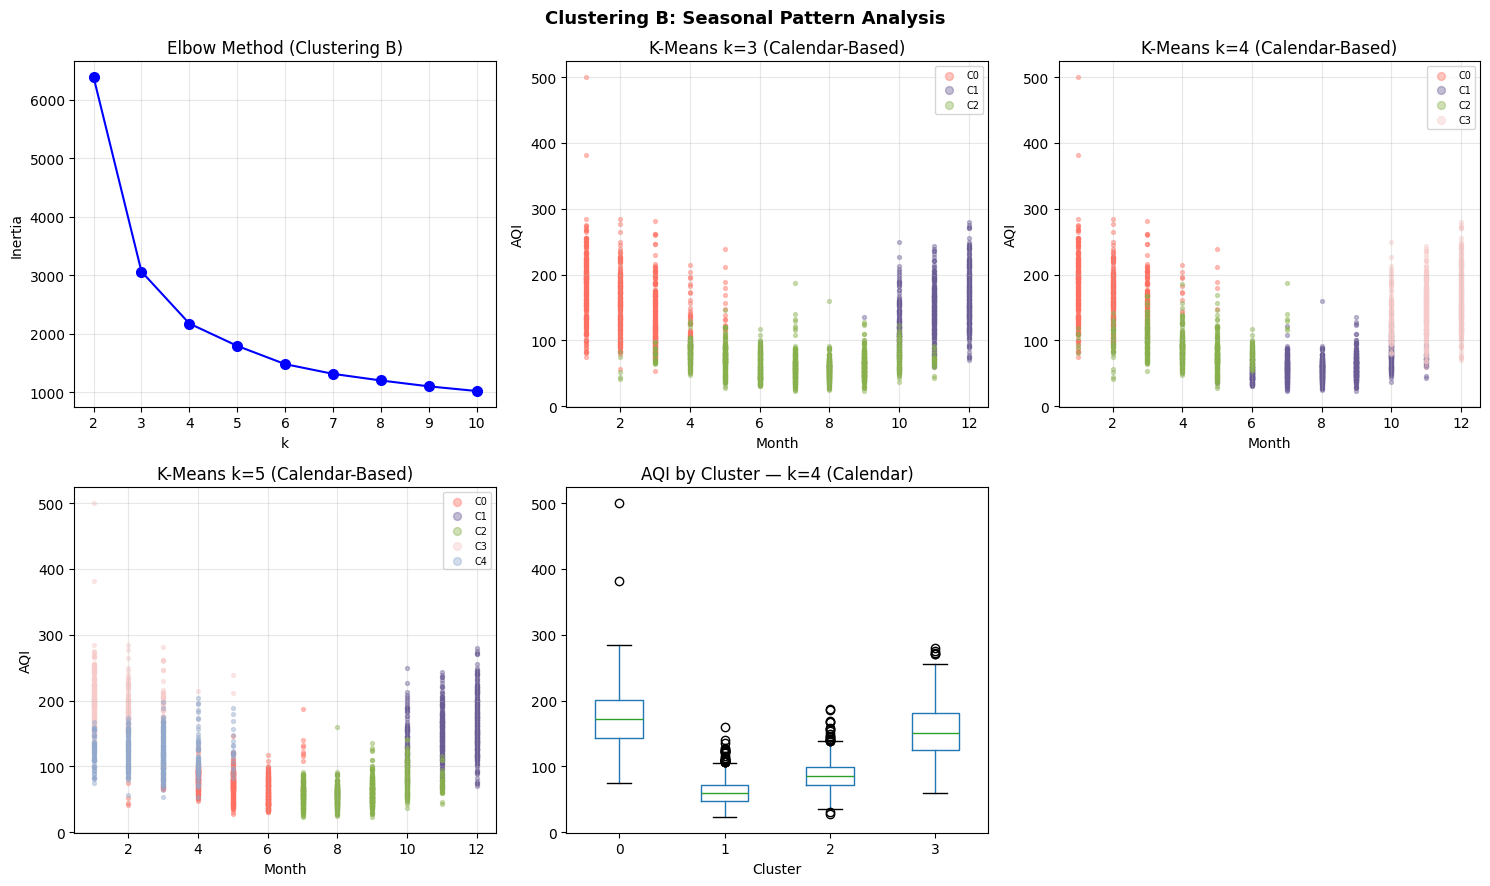

In [10]:
FEATURES_KB = ['AQI', 'AQI_roll7', 'month', 'day_of_year'] # Features include calendar information to capture seasonal patterns
X_kb = df_model[FEATURES_KB].dropna().reset_index(drop=True) # Prepare data for clustering

scaler_b = StandardScaler() # Initialize StandardScaler
X_kb_sc  = scaler_b.fit_transform(X_kb) # Scale features for KMeans

inertias_b = {k: KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_kb_sc).inertia_
              for k in range(2, 11)} # Calculate inertia for elbow method

fig, axes = plt.subplots(2, 3, figsize=(15, 9)) # Create subplots for visualization

axes[0, 0].plot(list(inertias_b.keys()), list(inertias_b.values()), 'bo-', markersize=7) # Plot the elbow curve
axes[0, 0].set_xlabel('k'); axes[0, 0].set_ylabel('Inertia')
axes[0, 0].set_title('Elbow Method (Clustering B)'); axes[0, 0].grid(alpha=0.3)

# Reuse the palette defined in the previous clustering section
# palette = ['#FF6F61', '#6B5B95', '#88B04B', '#F7CAC9', '#92A8CD']

for ax_pos, k in zip([(0,1),(0,2),(1,0)], [3, 4, 5]): # Create scatter plots for k=3, 4, 5
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_kb_sc) # Perform K-Means clustering
    ax = axes[ax_pos[0], ax_pos[1]] # Select current subplot axis
    for cid in range(k): # Plot each cluster with a distinct color
        mask = labels == cid
        ax.scatter(X_kb.loc[mask, 'month'], X_kb.loc[mask, 'AQI'],
                   s=8, alpha=0.4, color=palette[cid], label=f'C{cid}') # Scatter plot of Month vs AQI
    ax.set_title(f'K-Means k={k} (Calendar-Based)'); ax.set_xlabel('Month'); ax.set_ylabel('AQI')
    ax.legend(fontsize=7, markerscale=2); ax.grid(alpha=0.3)

labels_4b = KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(X_kb_sc) # Perform K-Means with optimal k=4
X_kb['Cluster_B'] = labels_4b # Assign cluster labels to the feature DataFrame
df_model['Cluster_B'] = labels_4b # Assign cluster labels back to the main DataFrame

X_kb.boxplot(column='AQI', by='Cluster_B', ax=axes[1,1], grid=False) # Box plot of AQI by cluster
axes[1,1].set_title('AQI by Cluster — k=4 (Calendar)'); axes[1,1].set_xlabel('Cluster'); plt.suptitle('')

axes[1,2].axis('off') # Turn off the unused subplot axis

profile_b = X_kb.groupby('Cluster_B')[['AQI','month']].agg({'AQI':'mean','month': lambda x: list(x.unique())}).round(1) # Characterize clusters by mean AQI and month
print("Clustering B — k=4 Profile (Calendar-Based):")
print(df_model.groupby('Cluster_B')[['AQI','month','AQI_roll7']].mean().round(1)) # Print a more detailed profile

plt.suptitle('Clustering B: Seasonal Pattern Analysis', fontsize=13, fontweight='bold') # Set overall suptitle
plt.tight_layout(); plt.show()

### Interpretation — Clustering B

The calendar-based clusters map closely to the four IMD meteorological seasons, confirming that Mumbai's AQI behaviour is strongly calendar-structured:

- **Cluster (Monsoon)**: Months 6–9, low AQI (~55–75) — heavy rainfall suppresses particulates
- **Cluster (Post-Monsoon)**: Months 10–11, transitional AQI (~100–130) — monsoon withdrawal removes the natural cleansing mechanism
- **Cluster (Winter)**: Months 12–2, highest AQI (~150–200+) — temperature inversions trap pollutants
- **Cluster (Pre-Monsoon)**: Months 3–5, moderate AQI (~100–140) — dry, dusty conditions with rising construction activity

The scatter plots (AQI vs Month) show clean vertical bands corresponding to seasons, with the monsoon band sitting well below the winter band.

### 6.3 Comparative Interpretation

**Clustering A** recovers *what kind* of pollution day it is — independent of when it occurs in the calendar. **Clustering B** recovers *when* pollution is highest — independent of its absolute signal characteristics.

Together, they confirm a key finding: **Mumbai's severe pollution (Clustering A, highest-AQI cluster) is not uniformly distributed across the calendar but is strongly concentrated in the winter and post-monsoon months (Clustering B)**. This intersection — high-pollution days that also fall in high-risk calendar windows — is where air quality interventions would have the greatest impact.

The consistency of k=4 as the optimal choice in both Elbow plots independently validates the four-regime interpretation and cross-confirms the physical structure of Mumbai's pollution calendar.

## 7. SARIMA Forecast

AQI is fundamentally a **time series** — past values are the primary source of information about future values. SARIMA (Seasonal ARIMA) models this directly without requiring any feature engineering.

**Model**: SARIMA(1,1,1)(1,1,0)[7]
- `(1,1,1)`: AR(1) + first differencing for stationarity + MA(1) for short-term noise
- `(1,1,0)[7]`: Seasonal AR(1) with weekly differencing — captures the day-of-week pattern in AQI

**Forecasting strategy**: `dynamic=False` — at each test step, the model uses the **actual observed value** from the previous step (not its own prior prediction). This is true one-step-ahead forecasting, equivalent to the rolling loop approach but computed in a single pass — orders of magnitude faster.

**Purpose**: This serves as a benchmark. If the Linear Regression model (Section 4) with its engineered features cannot beat SARIMA, it would suggest the lag features add no information beyond what the raw series already contains.

SARIMA  →  R²: 0.8275  |  RMSE: 23.8310


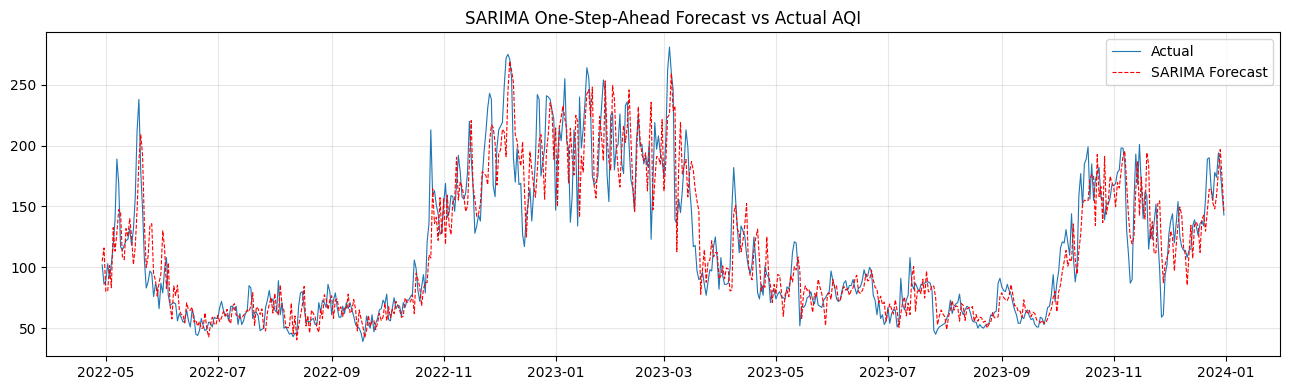

In [11]:
split_idx = int(len(ts) * 0.8) # Determine the 80/20 train-test split
test_s    = ts.iloc[split_idx:] # Test data

# Initialize and fit the SARIMA model
sarima = SARIMAX(ts, order=(1,1,1), seasonal_order=(1,1,0,7),
                 enforce_stationarity=False, enforce_invertibility=False)
fit = sarima.fit(disp=False) # Fit the SARIMA model without verbose output

# Generate one-step-ahead predictions on the test set
# dynamic=False ensures that actual previous values are used for forecasting, not previous forecasts
predictions = fit.predict(start=split_idx, end=len(ts)-1, dynamic=False)

mse_s = mean_squared_error(test_s, predictions) # Calculate Mean Squared Error
r2_s  = r2_score(test_s, predictions) # Calculate R-squared score
print(f"SARIMA  →  R²: {r2_s:.4f}  |  RMSE: {np.sqrt(mse_s):.4f}")

plt.figure(figsize=(13, 4))
plt.plot(test_s.index, test_s.values,      label='Actual', linewidth=0.8) # Plot actual values
plt.plot(test_s.index, predictions.values, label='SARIMA Forecast',
         linewidth=0.8, linestyle='--', color='red')
plt.title('SARIMA One-Step-Ahead Forecast vs Actual AQI')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.show()

### Interpretation

SARIMA with `dynamic=False` produces a true one-step-ahead forecast: at each day in the test set, the model uses the **actual previous day's AQI** as input. This is why the forecast tracks the actual series closely, including the monsoon dips and winter spikes.

**Benchmarking against Linear Regression**:
- If SARIMA's R² is comparable to or lower than the regression model's R² (~0.90), it confirms that the STL-based feature engineering adds genuine predictive value beyond pure autoregression
- If SARIMA outperforms the regression, it would suggest the feature set should be enriched — potentially by adding meteorological variables (temperature, wind speed) which drive the residual variation SARIMA captures via its MA term

**Limitation**: SARIMA models a **weekly seasonal period (s=7)**. The dominant annual cycle is handled implicitly through differencing and is not as explicitly modelled as in the STL decomposition approach. For a production forecasting system, a SARIMA(p,d,q)(P,D,Q)[365] or a hybrid STL-ARIMA model would be more appropriate.